<div style="display:flex; align-items:center; justify-content:space-between; gap:24px; border-bottom:2px solid #003b70; padding-bottom:14px; margin-bottom:20px;">
  <div>
    <h1 style="margin:0; color:#003b70;">Gaussian Processes Summer School</h1>
    <h2 style="margin:6px 0 10px 0; font-weight:500;">Part 3: Normalizing-Flow Spectral Kernels</h2>
    <p style="margin:0;"><strong>Author:</strong> <a href="https://olmos-pm.github.io/">Pablo M. Olmos</a><br><strong>Email:</strong> <a href="mailto:pamartin@ing.uc3m.es">pamartin@ing.uc3m.es</a></p>
  </div>
  <img src="https://www.uc3m.es/ss/Satellite?blobcol=urldata&amp;blobkey=id&amp;blobtable=MungoBlobs&amp;blobwhere=1371614316787&amp;ssbinary=true" alt="UC3M logo" style="width:220px; max-width:30%; height:auto;">
</div>

In this notebook, a **RealNVP-like normalizing flow** learns a flexible spectral distribution. We symmetrize its scalar frequency samples by random sign flips, use them as differentiable random Fourier features (RFFs), and learn the flow jointly with the GP hyperparameters by marginal likelihood. An $L_2$ frequency penalty discourages unnecessarily large frequencies.

## 1. Imports and reproducibility

The helper module `train_nf_spectral_gp.py` contains the flow, spectral kernel, GPyTorch model, regularized training loop, and sparse-signal prediction routine.

In [73]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from generate_gp_mixture import generate_gp_mixture
import train_nf_spectral_gp as nf_spectral_helpers
importlib.reload(nf_spectral_helpers)  # pick up local edits in an existing Jupyter kernel
from train_nf_spectral_gp import (
    as_tensors,
    build_nf_spectral_gp,
    predict_sparse_signal,
    train_nf_spectral_gp,
)

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)
torch.manual_seed(7)
rng = np.random.default_rng(7)


## 2. The same categorical GP mixture as Part 2

For every signal, first sample a component

$$z_i\sim\operatorname{Categorical}(\pi_1,\pi_2,\pi_3),$$

then sample a noisy curve

$$f_i\mid z_i=m\sim\mathcal{GP}(0,k_m),\qquad y_i(x_j)=f_i(x_j)+\epsilon_{ij},\quad \epsilon_{ij}\sim\mathcal N(0,\sigma_n^2),$$

with the stationary locally periodic kernel

$$k_m(\tau)=\exp\!\left(-\frac{\tau^2}{2\ell_m^2}\right)\cos(\omega_m\tau),\qquad \omega_m=\frac{2\pi}{T_m}.$$

On the finite grid, each exact GP draw is produced by $\mathbf f_i=L_m\boldsymbol\xi_i$, where $L_mL_m^\top=K_m+\varepsilon I$ and $\boldsymbol\xi_i\sim\mathcal N(0,I)$. Thus, RFFs are used for the **fitted model**, not to generate the data.

By Bochner's theorem, the normalized spectrum of component $m$ is

$$p_m(\omega)=\tfrac12\mathcal N(\omega;\omega_m,\ell_m^{-2})+\tfrac12\mathcal N(\omega;-\omega_m,\ell_m^{-2}),$$

and the population-average spectrum is $p_{\rm true}(\omega)=\sum_m\pi_m p_m(\omega)$. One shared GP therefore learns the **population-average covariance**, rather than identifying a different kernel for each test signal.

In [74]:
seed = 7
n_curves = 300
x = np.linspace(0.0, 2.0, 200)
periods = np.array([1.0, 0.5, 0.25])
angular_frequencies = 2 * np.pi / periods
lengthscales = np.array([0.6, 0.6, 0.6])
mixture_weights = np.array([1/3, 1/3, 1/3])
noise_std = 0.05

curves, labels = generate_gp_mixture(
    x=x,
    n_curves=n_curves,
    periods=periods,
    lengthscales=lengthscales,
    mixture_weights=mixture_weights,
    noise_std=noise_std,
    seed=seed,
)

split_rng = np.random.default_rng(seed + 2)
permutation = split_rng.permutation(n_curves)
n_train = int(0.8 * n_curves)
train_idx, test_idx = permutation[:n_train], permutation[n_train:]
train_curves, test_curves = curves[train_idx], curves[test_idx]
train_labels, test_labels = labels[train_idx], labels[test_idx]

pd.DataFrame({
    'component': np.arange(1, 4),
    'period $T_m$': periods,
    'angular frequency $\\omega_m$': angular_frequencies,
    'lengthscale $\\ell_m$': lengthscales,
    'population weight': mixture_weights,
    'training share': np.bincount(train_labels, minlength=3) / n_train,
})


,component,period $T_m$,angular frequency $\omega_m$,lengthscale $\ell_m$,population weight,training share
0,1,1.00,6.283185,0.6,0.333333,0.3125
1,2,0.50,12.566371,0.6,0.333333,0.3500
2,3,0.25,25.132741,0.6,0.333333,0.3375


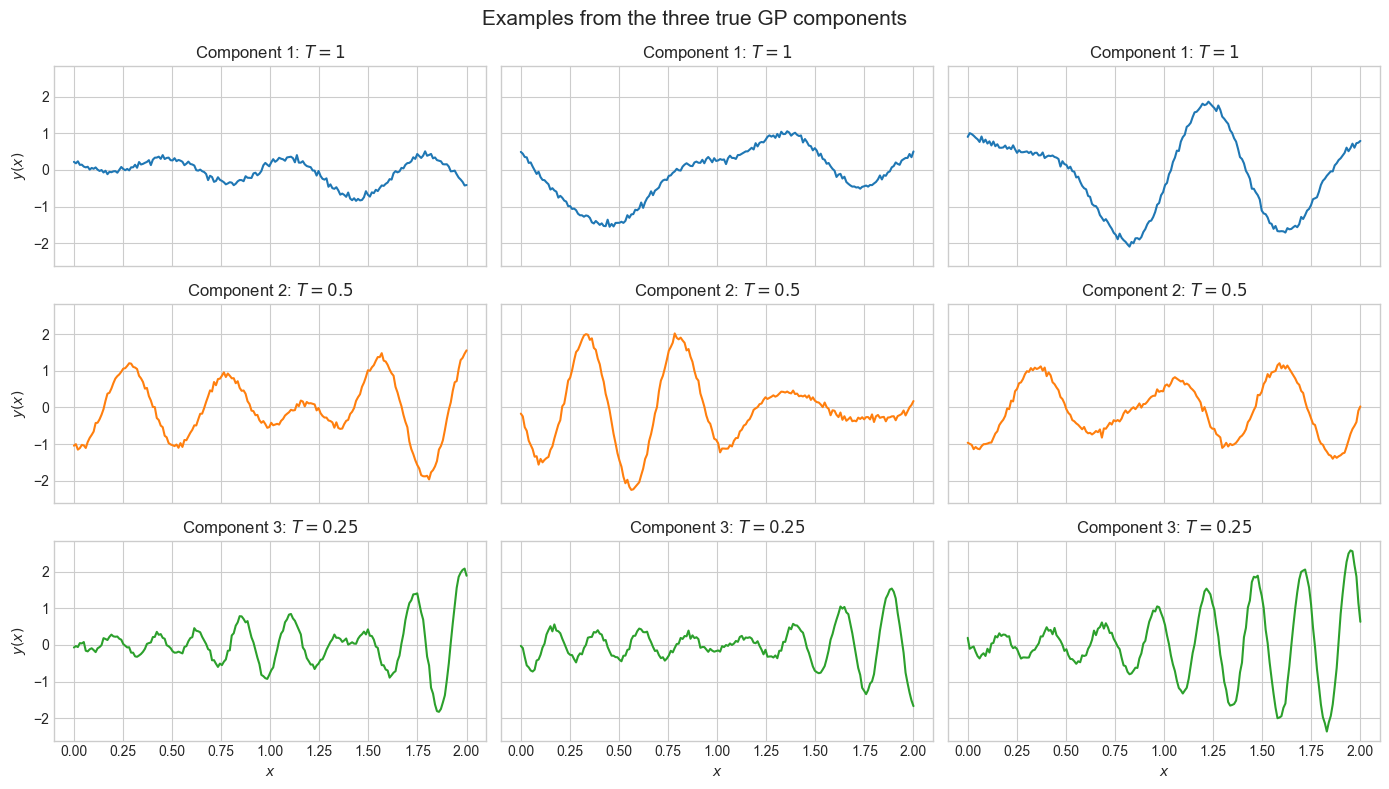

In [75]:
fig, axes = plt.subplots(3, 3, figsize=(14, 8), sharex=True, sharey=True)
for component in range(3):
    component_indices = np.flatnonzero(labels == component)[:3]
    for column, curve_index in enumerate(component_indices):
        axes[component, column].plot(x, curves[curve_index], color=f'C{component}', lw=1.5)
        axes[component, column].set_title(
            f'Component {component + 1}: $T={periods[component]:g}$'
        )
for ax in axes[-1]:
    ax.set_xlabel('$x$')
for ax in axes[:, 0]:
    ax.set_ylabel('$y(x)$')
fig.suptitle('Examples from the three true GP components', fontsize=15)
fig.tight_layout()
plt.show()


## 3. A RealNVP-like spectral distribution

A one-dimensional affine coupling layer is degenerate, so we begin with a two-dimensional base variable

$$\mathbf z\sim\mathcal N(\mathbf 0,I_2).$$

Each RealNVP layer leaves one masked coordinate unchanged and transforms the other:

$$\mathbf u_A=\mathbf z_A,\qquad \mathbf u_B=\mathbf z_B\odot\exp(s_\theta(\mathbf z_A))+t_\theta(\mathbf z_A).$$

Alternating the mask over several layers gives an invertible map $T_\theta$. We take its first output coordinate and a learned positive scale $a_\theta$ to define a scalar raw frequency,

$$\widetilde\omega=a_\theta[T_\theta(\mathbf z)]_1.$$

This is an implicit one-dimensional marginal of the two-dimensional flow. We then draw $b\in\{-1,+1\}$ with equal probability and set

$$\omega=b\widetilde\omega.$$

Consequently, if $q_\theta$ denotes the raw scalar density,

$$p_\theta(\omega)=\tfrac12q_\theta(\omega)+\tfrac12q_\theta(-\omega),$$

which is symmetric and yields a real stationary kernel through Bochner's theorem.

<div style="display:block; box-sizing:border-box; width:100%; max-width:100%; overflow-x:auto; white-space:normal; background:#e8f3ff; border-left:6px solid #1976d2; padding:14px 18px; margin:16px 0;">
<strong>Fresh Monte Carlo samples at every step</strong><br>
At optimization step $t$, we redraw $\{\mathbf z_d^{(t)},b_d^{(t)}\}_{d=1}^D$ and form $\omega_d^{(t)}=b_d^{(t)}a_\theta[T_\theta(\mathbf z_d^{(t)})]_1$. Conditional on that draw, the frequencies are differentiable with respect to the flow parameters. Redrawing estimates the expectation over the spectral distribution instead of optimizing one permanently fixed RFF realization, although it also introduces Monte Carlo noise. The random-number generator is seeded so the notebook remains reproducible.
</div>

The paired RFF map is

$$\phi_\theta(x)=\frac1{\sqrt D}\big[\cos(\omega_1x),\ldots,\cos(\omega_Dx),\sin(\omega_1x),\ldots,\sin(\omega_Dx)\big],$$

so

$$k_\theta(x,x')\approx \phi_\theta(x)^\top\phi_\theta(x')=\frac1D\sum_{d=1}^D\cos\big(\omega_d(x-x')\big).$$

Because cosine is even, flipping a sign does not change an individual paired sine/cosine kernel contribution. The sign flip is nevertheless useful: it makes the sampled spectral measure explicitly symmetric and gives the correct two-sided spectral visualization.

## 4. Regularized evidence training

The shared GP hyperparameters, output scale, noise variance, frequency scale, and all flow-network weights are trained jointly. With $B$ training curves, we minimize

$$\mathcal J(\theta)=-\frac1B\sum_{i=1}^B\log p(\mathbf y_i\mid X,\theta)+\lambda_\omega\frac1D\sum_{d=1}^D\omega_d^2.$$

The first term is the negative GP log marginal likelihood. The second is an $L_2$ norm penalty on the sampled frequencies.

<div style="display:block; box-sizing:border-box; width:100%; max-width:100%; overflow-x:auto; white-space:normal; background:#fff4e5; border-left:6px solid #ef6c00; padding:14px 18px; margin:16px 0;">
<strong>Regularization trade-off.</strong><br>
Large $|\omega|$ means rapid oscillation. The penalty suppresses spurious high-frequency mass that can explain noise, stabilizing the learned spectrum. However, too large a value of $\lambda_\omega$ biases all bands toward zero and may erase the genuine highest-frequency component. It should therefore be mild and inspected together with the learned spectrum and validation behavior.
</div>

In [ ]:
train_x_t, train_y_t = as_tensors(x, train_curves)

nf_model, nf_likelihood = build_nf_spectral_gp(
    train_x_t,
    train_y_t,
    num_frequencies=256,
    num_flow_layers=6,
    hidden_features=64,
    initial_frequency_scale=10.0,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
    seed=31,
)

frequency_penalty_weight = 1e-4
history = train_nf_spectral_gp(
    nf_model,
    nf_likelihood,
    train_x_t,
    train_y_t,
    num_steps=1000,
    learning_rate=0.003,
    frequency_penalty_weight=frequency_penalty_weight,
    resample_frequencies_each_step=True,
    resampling_seed=2026,
    print_every=200,
)


step    1/1000 | objective=-0.7414 | NLL=-0.7514 | freq RMS=10.035 | noise=0.00251
step  200/1000 | objective=-1.0996 | NLL=-1.1284 | freq RMS=16.973 | noise=0.00250


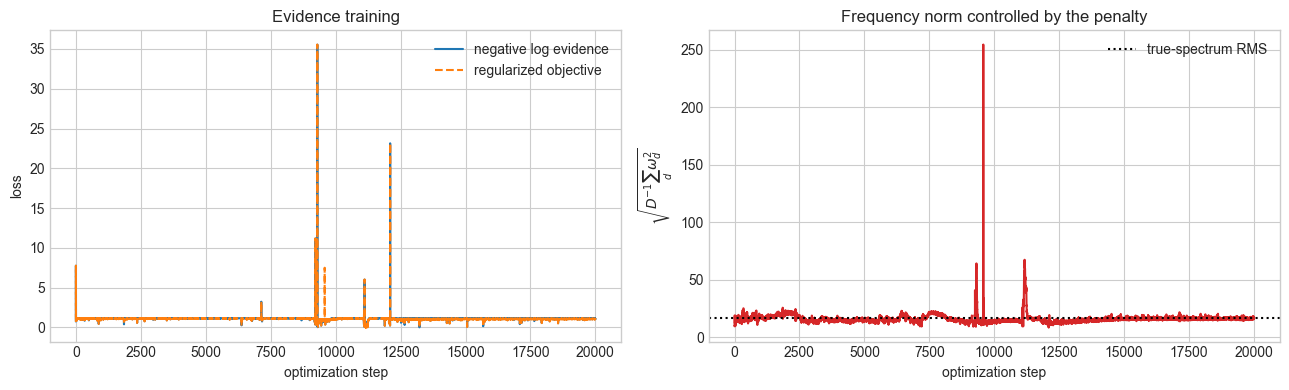

,quantity,learned value
0,output variance,1.652611
1,noise variance,0.002493
2,frequency scale,1.409143
3,frequency RMS,17.267164
4,penalty weight,0.000100


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.abs(history.negative_mll), label='negative log evidence')
axes[0].plot(np.abs(history.objective), '--', label='regularized objective')
axes[0].set(xlabel='optimization step', ylabel='loss', title='Evidence training')
axes[0].legend()

axes[1].plot(history.frequency_rms, color='C3')
axes[1].axhline(np.sqrt(np.sum(mixture_weights * (angular_frequencies**2 + lengthscales**-2))),
                color='black', ls=':', label='true-spectrum RMS')
axes[1].set(xlabel='optimization step', ylabel=r'$\sqrt{D^{-1}\sum_d\omega_d^2}$',
            title='Frequency norm controlled by the penalty')
axes[1].legend()
fig.tight_layout()
plt.show()

kernel = nf_model.covar_module.base_kernel
pd.DataFrame({
    'quantity': ['output variance', 'noise variance', 'frequency scale',
                 'frequency RMS', 'penalty weight'],
    'learned value': [
        float(nf_model.covar_module.outputscale.detach()),
        float(nf_likelihood.noise.detach()),
        float(kernel.frequency_scale.detach()),
        history.frequency_rms[-1],
        frequency_penalty_weight,
    ],
})


## 5. Did the flow recover the aggregate spectrum?

We compare fresh samples from the symmetrized flow with the analytic population spectrum. Exact agreement is not expected: the model sees a finite training sample, uses a finite RFF approximation, and is deliberately frequency-regularized.

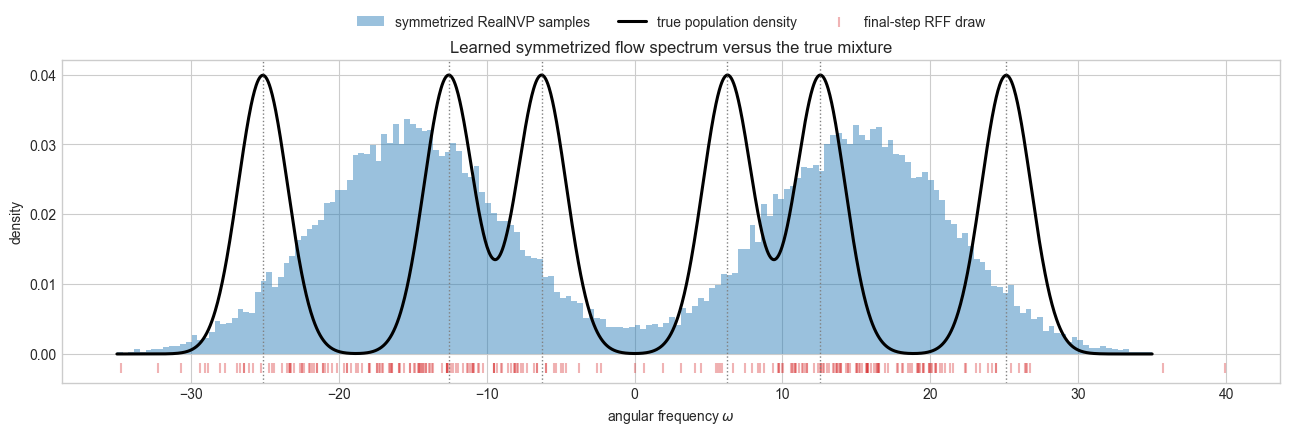

In [ ]:
nf_model.eval()
nf_likelihood.eval()
with torch.no_grad():
    learned_frequency_samples = kernel.draw_frequencies(40_000, seed=2026).cpu().numpy()
    training_frequencies = kernel.frequencies().cpu().numpy()

omega_grid = np.linspace(-35, 35, 1800)
true_density = np.zeros_like(omega_grid)
for weight, center, ell in zip(mixture_weights, angular_frequencies, lengthscales):
    spectral_std = 1 / ell
    normalizer = spectral_std * np.sqrt(2 * np.pi)
    true_density += 0.5 * weight * np.exp(-0.5 * ((omega_grid-center)/spectral_std)**2) / normalizer
    true_density += 0.5 * weight * np.exp(-0.5 * ((omega_grid+center)/spectral_std)**2) / normalizer

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.hist(learned_frequency_samples, bins=180, range=(-35, 35), density=True,
        alpha=0.45, color='C0', label='symmetrized RealNVP samples')
ax.plot(omega_grid, true_density, color='black', lw=2.2, label='true population density')
ax.scatter(training_frequencies, np.full_like(training_frequencies, -0.002),
           marker='|', s=45, alpha=0.35, color='C3', label='final-step RFF draw')
for center in angular_frequencies:
    ax.axvline(center, color='gray', ls=':', lw=1)
    ax.axvline(-center, color='gray', ls=':', lw=1)
ax.set(xlabel=r'angular frequency $\omega$', ylabel='density',
       title='Learned symmetrized flow spectrum versus the true mixture')
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.18))
fig.tight_layout()
plt.show()


The density plot is the most direct test of spectral recovery, but the induced covariance is what matters to the GP. The true population covariance is

$$k_{\rm avg}(\tau)=\sum_m\pi_m\exp\!\left(-\frac{\tau^2}{2\ell_m^2}\right)\cos(\omega_m\tau).$$

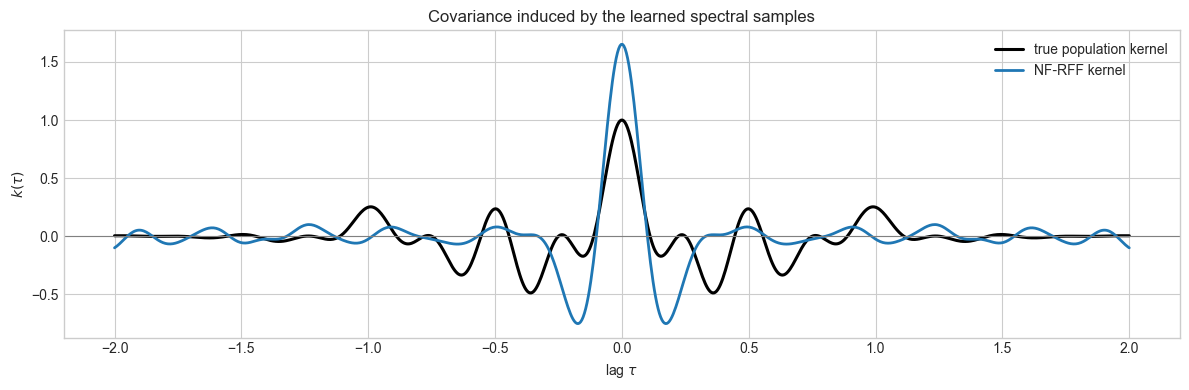

In [106]:
tau = np.linspace(-2, 2, 800)
true_kernel = sum(
    weight * np.exp(-tau**2 / (2 * ell**2)) * np.cos(center * tau)
    for weight, center, ell in zip(mixture_weights, angular_frequencies, lengthscales)
)
outputscale = float(nf_model.covar_module.outputscale.detach())
learned_kernel = outputscale * np.cos(tau[:, None] * training_frequencies[None, :]).mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau, true_kernel, color='black', lw=2.2, label='true population kernel')
ax.plot(tau, learned_kernel, color='C0', lw=2, label='NF-RFF kernel')
ax.axhline(0, color='gray', lw=0.8)
ax.set(xlabel=r'lag $\tau$', ylabel=r'$k(\tau)$',
       title='Covariance induced by the learned spectral samples')
ax.legend()
fig.tight_layout()
plt.show()


## 6. Sparse observations from held-out signals

For every held-out curve below, observation locations are sampled independently and non-uniformly. The globally learned flow and kernel stay fixed; only that signal's sparse observations are used for GP conditioning.

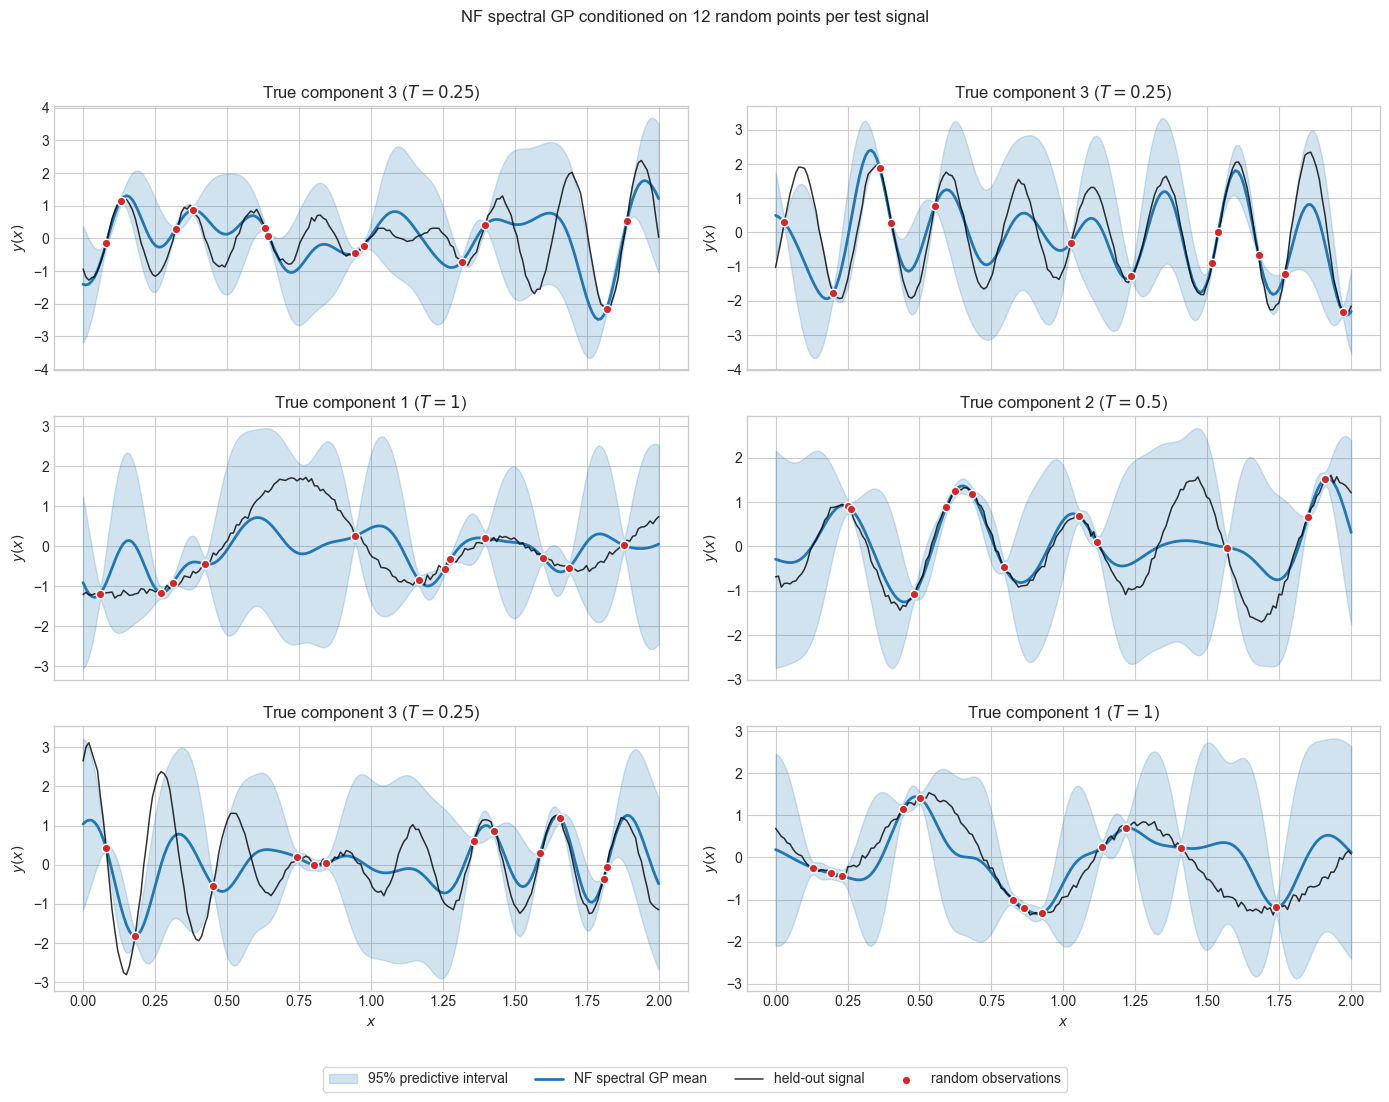

In [103]:
n_examples = 6
n_observed = 12
display_rng = np.random.default_rng(113)
chosen_test = display_rng.choice(len(test_curves), size=n_examples, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
axes = axes.ravel()
legend_handles = None
legend_labels = None

for ax, test_position in zip(axes, chosen_test):
    observed_indices = np.sort(display_rng.choice(len(x), size=n_observed, replace=False))
    prediction = predict_sparse_signal(
        nf_model,
        nf_likelihood,
        observed_x=x[observed_indices],
        observed_y=test_curves[test_position, observed_indices],
        prediction_x=x,
    )
    ax.fill_between(x, prediction.lower, prediction.upper, color='C0', alpha=0.2,
                    label='95% predictive interval')
    ax.plot(x, prediction.mean, color='C0', lw=2, label='NF spectral GP mean')
    ax.plot(x, test_curves[test_position], color='black', lw=1.1, alpha=0.8,
            label='held-out signal')
    ax.scatter(x[observed_indices], test_curves[test_position, observed_indices],
               color='C3', edgecolor='white', s=38, zorder=4, label='random observations')
    component = test_labels[test_position]
    ax.set_title(f'True component {component + 1} ($T={periods[component]:g}$)')
    ax.set_ylabel('$y(x)$')
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

for ax in axes[-2:]:
    ax.set_xlabel('$x$')
fig.suptitle(f'NF spectral GP conditioned on {n_observed} random points per test signal', y=0.995)
fig.legend(legend_handles, legend_labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, 0.005), frameon=True)
fig.tight_layout(rect=(0, 0.055, 1, 0.97))
plt.show()


## 7. Conclusions

- A RealNVP-like map turns simple Gaussian noise into a flexible implicit spectral law; its first-coordinate marginal can represent structure beyond a single Gaussian spectrum.
- Random sign flips explicitly symmetrize the spectral samples, ensuring compatibility with a real stationary covariance. With paired sine/cosine features the kernel itself is already even in frequency.
- Resampling the base noise and signs at every iteration trains against multiple Monte Carlo realizations of the spectral law. The pathwise map remains differentiable, but the objective is noisier than with fixed features.
- The shared model targets the **aggregate mixture kernel**. It does not infer a separate component label or kernel for each signal.
- The $L_2$ frequency penalty is a useful guard against spurious rapid oscillations, but it trades variance for bias: excessive regularization can suppress a genuine high-frequency band.
- Inspect both spaces. A visually imperfect density may still induce a good covariance on the observed lag range, while apparent spectral peaks do not guarantee good held-out conditioning.